In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pickle

In [2]:
orders = pd.read_csv("olist_orders_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
print("Datasets loaded successfully")

Datasets loaded successfully


In [3]:
df = orders.merge(payments, on="order_id")
df = df.merge(items, on="order_id")
print("Datasets merged")
df.head()

Datasets merged


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,1,18.12,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,1,2.00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,1,18.59,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22


In [4]:
df["revenue"] = df["price"] + df["freight_value"]
df[["price", "freight_value", "revenue"]].head()

,price,freight_value,revenue
0,29.99,8.72,38.71
1,29.99,8.72,38.71
2,29.99,8.72,38.71
3,118.70,22.76,141.46
4,159.90,19.22,179.12


In [5]:
print(df.isnull().sum())
df = df.dropna()
print("After cleaning:")
print(df.isnull().sum())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1245
order_delivered_customer_date    2567
order_estimated_delivery_date       0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
revenue                             0
dtype: int64
After cleaning:
order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
orde

In [6]:
df = df[[
    "price",
    "freight_value",
    "payment_value",
    "payment_installments"
]]
df.head()

,price,freight_value,payment_value,payment_installments
0,29.99,8.72,18.12,1
1,29.99,8.72,2.00,1
2,29.99,8.72,18.59,1
3,118.70,22.76,141.46,1
4,159.90,19.22,179.12,3


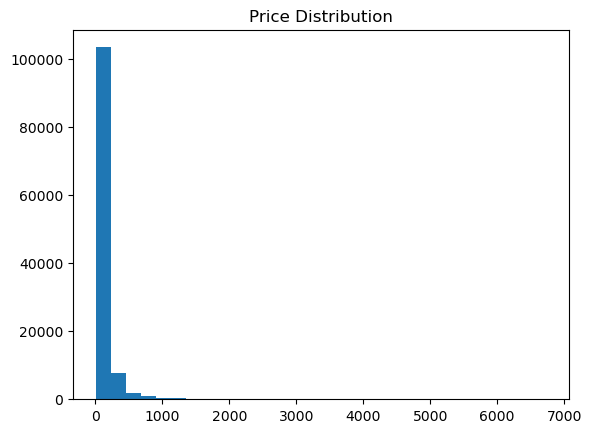

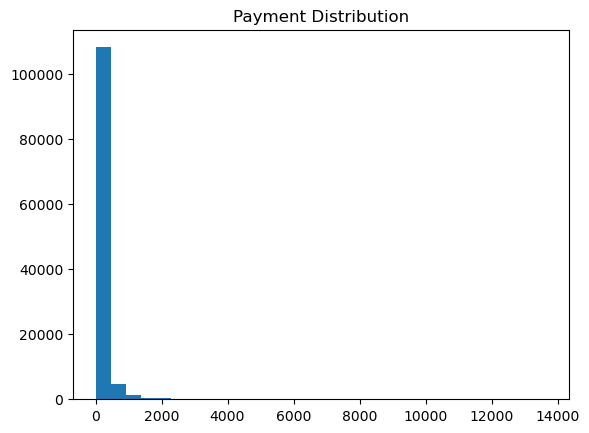

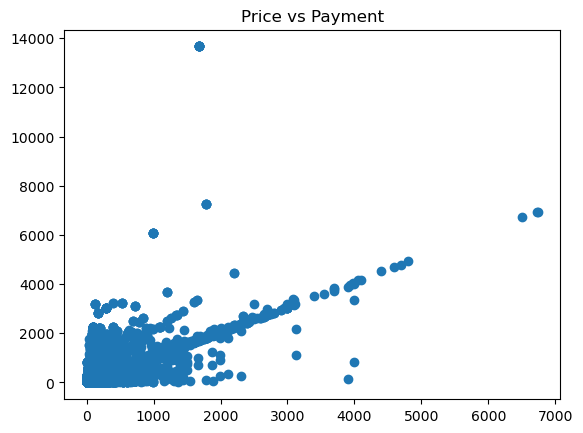

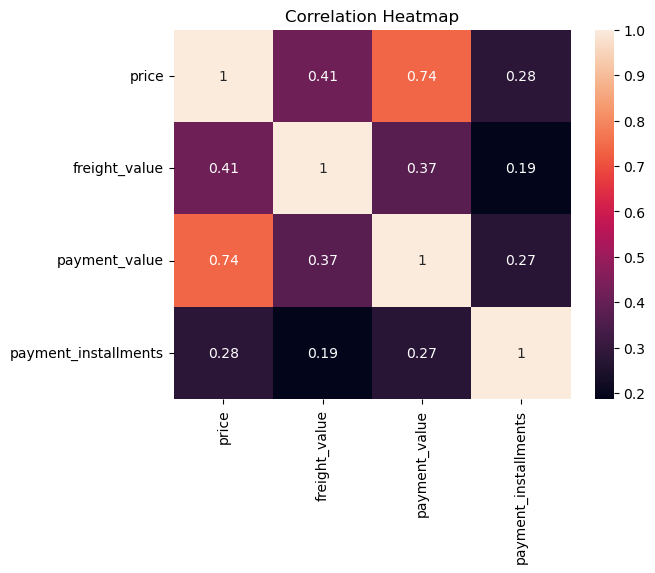

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Price Distribution
plt.figure()
plt.hist(df["price"], bins=30)
plt.title("Price Distribution")
plt.show()

# Payment Distribution
plt.figure()
plt.hist(df["payment_value"], bins=30)
plt.title("Payment Distribution")
plt.show()

# Scatter Plot
plt.figure()
plt.scatter(df["price"], df["payment_value"])
plt.title("Price vs Payment")
plt.show()

# Heatmap
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [7]:
X = df.drop("payment_value", axis=1)
y = df["payment_value"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Data split completed")

Data split completed


In [20]:
lr = LinearRegression()
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
xgb = XGBRegressor()
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
print("Models trained")

Models trained


In [21]:
y_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

In [22]:
print("Linear Regression R2:", r2_score(y_test, y_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))
print("XGBoost R2:", r2_score(y_test, xgb_pred))

print("\nMAE:", mean_absolute_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

Linear Regression R2: 0.5692743700338043
Random Forest R2: 0.7996182590901396
XGBoost R2: 0.7082246280670248

MAE: 54.159493046778636
RMSE: 139.8474727111371


In [24]:
pickle.dump(rf, open("sales_model.pkl", "wb"))
print("Model saved successfully")

Model saved successfully
